# Analysis of Youth Drug Use

In [311]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree, DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.inspection import PartialDependenceDisplay

## Importing Data

In [805]:
youth_data = pd.read_csv("youth_data.csv")
yth_data = youth_data.copy()

## Removing Values that would Skew Data

In [807]:
# All values over 400 were indicating no use for yearly counts of substance use 
# so I set them to 0 to indicate no use
yth_data = yth_data.mask(yth_data > 400, 0)

# Values over 31 indicated no use or never using so I set them to 0 to indicate no use,
# For days skipped of school, values over 30 were either blank, unknown, or skipped
# so I set them to zero since making it an ordered factor didn't make sense as it 
# was not catigorical
cols_to_modify2 =  ['IRCIGFM', 'IRSMKLSS30N', 'IRALCFM', 'IRMJFM', 'EDUSKPCOM']
yth_data.loc[:, cols_to_modify2] = yth_data.loc[:, cols_to_modify2].mask(
    yth_data.loc[:, cols_to_modify2] >= 35, 0)


# Dropped cigarette ordered use as it didn't match the other ordered uses
# Dropped Alcohol and Marijuana ordered use as I planned to use the days used 1-365
yth_data = yth_data.drop(['CIGMDAYS', 'ALCYDAYS', 'MRJYDAYS'], axis = 1)

## Factoring Data

In [810]:
# Ordered Factor: Yes, No, Unknown, Adult
for col in ['IMOTHER', 'IFATHER']:
    yth_data[col] = pd.Categorical(
        yth_data[col].replace({1: "Yes", 2: "No", 3: "Unknown"}),
        categories = ["Yes", "No", "Unknown"]
    )

# Binary: Sex: Male/Female
yth_data['IRSEX'] = yth_data['IRSEX'].replace({1: "M", 2: "F"}).astype(pd.CategoricalDtype(categories=["M", "F"]))

# Binary: Health: Unknown, Excellent, Very Good, Good, Fair/Poor
yth_data['HEALTH2'] = yth_data['HEALTH2'].replace({1: "Excellent", 2: "Very Good",
                                                   3: "Good", 4: "Fair/Poor"
      }).astype(pd.CategoricalDtype(categories = ["Excellent", "Very Good", "Good", "Fair/Poor"]))

# Ordered Factor: Going to School: Yes, No, Unknown
yth_data['EDUSCHLGO'] = yth_data['EDUSCHLGO'].replace({1: "Yes", 2: "No", 11: "Yes", 85: "Unknown",
                                                       94: "Unknown", 97: "Unknown", 98: "Unknown"
      }).astype(pd.CategoricalDtype(categories=["Yes", "No", "Unknown"]))

# Ordered Factor: Family Income: Less than 20k, 20k-50k, 50k-75k, 75k+
yth_data['INCOME'] = yth_data['INCOME'].replace({1: "Less than 20k", 2: "20k-50k", 3: "50k-75k", 4: "75k+"
      }).astype(pd.CategoricalDtype(categories = ["Less than 20k", "20k-50k", "50k-75k", "75k+"]))

# Ordered Factor: Race: White, Black, Native, Pacific Islander, Asian, Mixed, Hispanic
yth_data['NEWRACE2'] = yth_data['NEWRACE2'].replace({1: "White", 2: "Black", 3: "Native", 4: "Pacific Islander",
                                                 5: "Asian", 6: "Mixed", 7: "Hispanic"
      }).astype(pd.CategoricalDtype(categories = ["White", "Black", "Native", "Pacific Islander", 
                                                "Asian", "Mixed", "Hispanic"]))

# Ordered Factor: Metro
yth_data['COUTYP4'] = yth_data['COUTYP4'].replace({1: "Large Metro", 2: "Small Metro", 3: "Nonmetro"
      }).astype(pd.CategoricalDtype(categories = ["Large Metro", "Small Metro", "Nonmetro"]))

# Ordered Factor: Poverty
yth_data['POVERTY3'] = yth_data['POVERTY3'].replace({1: "In Poverty", 2: "Middle Class", 3: "Wealthy"
      }).astype(pd.CategoricalDtype(categories = ["In Poverty", "Middle Class", "Wealthy"]))

# Ordered Factor: Grade
# Turned Specific Grades into Middle School/High School/College
yth_data['EDUSCHGRD2'] = yth_data['EDUSCHGRD2'].replace({1: "Middle School", 2: "Middle School", 3: "Middle School", 
                                                         4: "Middle School", 5: "High School", 6: "High School", 
                                                         7: "High School", 8: "High School", 9: "College", 
                                                         10: "College", 11: "College", 12: "College", 
                                                         98: "Skip", 99: "Skip", 
      }).astype(pd.CategoricalDtype(categories = ["Middle School", "High School", "College", "Skip"]))


# Ordered Factor: seldom, sometimes, often, very frequently, none
for col in ['ALCMDAYS', 'MRJMDAYS','SMKLSMDAYS']:
    yth_data[col] = pd.Categorical(
        yth_data[col].map({
            1: "Seldom", 
            2: "Sometimes", 
            3: "Often", 
            4: "Very Frequently", 
            5: "None"
        }),
        categories = ["Seldom", "Sometimes", "Often", "Very Frequently", "None"],
        ordered = True
    )


## Looking at the Factored Data

In [813]:
# Looking to ensure the factors were done correctly
for col in yth_data.columns:
    val_counts = yth_data[col].value_counts()
    print(f"Column: {col}")
    print(val_counts)
    print("\n") 

Column: IRALCFY
IRALCFY
0      8696
1       326
2       221
3       190
5       121
12      113
24       99
52       90
4        87
36       71
6        54
48       43
10       40
8        38
60       35
104      34
7        27
20       21
15       18
156      18
9        12
11       10
14       10
13       10
84        9
96        8
30        8
208       7
144       7
18        7
120       6
72        6
50        6
16        6
180       6
26        5
260       5
29        5
35        5
19        4
25        4
21        4
22        3
108       3
81        3
17        3
32        3
312       2
54        2
23        2
42        2
27        2
46        2
90        2
339       2
56        2
31        2
49        2
100       2
55        1
101       1
73        1
28        1
112       1
168       1
45        1
53        1
34        1
175       1
61        1
134       1
86        1
67        1
245       1
40        1
234       1
41        1
79        1
240       1
37        1
43        1
246 

## Turning Factors into Label Encoding and One-Hot Encoding

In [817]:
# Binary Variables
lb = LabelBinarizer()
transform = ['IRSEX']

for col in transform:
    yth_data[col] = lb.fit_transform(yth_data[col])

# One-Hot Encoded Categorical Variables
transform_cols = ['NEWRACE2', 'HEALTH2', 'EDUSCHLGO', 'EDUSCHGRD2', 
                   'IMOTHER', 'IFATHER', 'INCOME', 'POVERTY3', 'PDEN10',
                   'COUTYP4', 'ALCMDAYS', 'MRJMDAYS', 'SMKLSMDAYS']
yth_data_encoded = pd.get_dummies(yth_data, columns = transform_cols, drop_first = False)

## Splitting into Groups

In [820]:
# Questions related to the youth's demographics
demographics = yth_data[['IRSEX', 'NEWRACE2', 'HEALTH2', 'EDUSCHLGO', 'EDUSCHGRD2', 'EDUSKPCOM',
       'IMOTHER', 'IFATHER', 'INCOME', 'GOVTPROG', 'POVERTY3', 'PDEN10',
       'COUTYP4']]

# Questions related to the youth's life experiences
youth_experiences = yth_data[['SCHFELT', 'TCHGJOB', 'AVGGRADE', 'STNDSCIG', 'STNDSMJ',
       'STNDALC', 'STNDDNK', 'PARCHKHW', 'PARHLPHW', 'PRCHORE2', 'PRLMTTV2',
       'PARLMTSN', 'PRGDJOB2', 'PRPROUD2', 'ARGUPAR', 'YOFIGHT2', 'YOGRPFT2',
       'YOHGUN2', 'YOSELL2', 'YOSTOLE2', 'YOATTAK2', 'PRPKCIG2', 'PRMJEVR2',
       'PRMJMO', 'PRALDLY2', 'YFLPKCG2', 'YFLTMRJ2', 'YFLMJMO', 'YFLADLY2',
       'FRDPCIG2', 'FRDMEVR2', 'FRDMJMON', 'FRDADLY2', 'TALKPROB', 'PRTALK3',
       'PRBSOLV2', 'PREVIOL2', 'PRVDRGO2', 'GRPCNSL2', 'PREGPGM2', 'YTHACT2',
       'DRPRVME3', 'ANYEDUC3', 'RLGATTD', 'RLGIMPT', 'RLGDCSN', 'RLGFRND']]

# Questions related to the youth's substance use
substance_use = yth_data[['IRALCFY', 'IRMJFY', 'IRCIGFM', 'IRSMKLSS30N', 'IRALCFM', 'IRMJFM',
       'IRCIGAGE', 'IRSMKLSSTRY', 'IRALCAGE', 'IRMJAGE', 'MRJFLAG', 'ALCFLAG',
       'TOBFLAG', 'ALCMDAYS', 'MRJMDAYS', 'SMKLSMDAYS']]

demographics.head()

,IRSEX,NEWRACE2,HEALTH2,EDUSCHLGO,EDUSCHGRD2,EDUSKPCOM,IMOTHER,IFATHER,INCOME,GOVTPROG,POVERTY3,PDEN10,COUTYP4
0,1,Hispanic,Good,Yes,Middle School,0,Yes,Yes,20k-50k,2,In Poverty,2,Small Metro
1,0,White,Fair/Poor,Yes,High School,0,Yes,Yes,20k-50k,2,In Poverty,2,Small Metro
2,1,Mixed,Excellent,Yes,Middle School,1,Yes,Yes,75k+,2,Wealthy,1,Large Metro
3,0,Hispanic,Very Good,Yes,Middle School,0,Yes,Yes,50k-75k,2,Middle Class,1,Large Metro
4,1,White,Excellent,Yes,High School,0,Yes,Yes,75k+,2,Wealthy,2,Small Metro


## Youth Acohol Binary Classification
### Binary Classification Decision Tree

In [823]:
yth_data_encoded.iloc[:,40:]

,YFLMJMO,YFLADLY2,FRDPCIG2,FRDMEVR2,FRDMJMON,FRDADLY2,TALKPROB,PRTALK3,PRBSOLV2,PREVIOL2,...,MRJMDAYS_Seldom,MRJMDAYS_Sometimes,MRJMDAYS_Often,MRJMDAYS_Very Frequently,MRJMDAYS_None,SMKLSMDAYS_Seldom,SMKLSMDAYS_Sometimes,SMKLSMDAYS_Often,SMKLSMDAYS_Very Frequently,SMKLSMDAYS_None
0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,...,False,False,False,False,True,False,False,False,False,True
1,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,...,True,False,False,False,False,False,False,False,False,True
2,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,...,False,False,False,False,True,False,False,False,False,True
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,...,False,False,False,False,True,False,False,False,False,True
4,2.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,...,False,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10556,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,...,False,False,False,False,True,False,False,False,False,True
10557,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,...,False,False,False,False,True,False,False,False,False,True
10558,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,...,False,False,False,False,True,False,False,False,False,True
10559,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,...,False,False,False,False,True,False,False,False,False,True


In [825]:
# Predicting ALCFLAG

# Dropping encoded variables that also refer to alcohol use
patterns = ['ALCMDAYS']
drop_cols = yth_data_encoded.columns[yth_data_encoded.columns.str.contains('|'.join(patterns))]
yth_data_encoded_bc =  yth_data_encoded.copy().drop(columns = drop_cols)
yth_data_encoded_bc =  yth_data_encoded_bc.drop(columns = ["IRALCFY", "IRALCAGE", "IRALCFM"])

train_data, test_data = train_test_split(yth_data_encoded_bc, train_size = 800, random_state = 2)

X_train = train_data.drop(columns = ['ALCFLAG'])
y_train = train_data['ALCFLAG']
X_test = test_data.drop(columns = ['ALCFLAG'])
y_test = test_data['ALCFLAG']

tree_yth_bc = DecisionTreeClassifier(random_state = 1)
tree_yth_bc.fit(X_train, y_train)
y_pred_bc = tree_yth_bc.predict(X_test)

#### Unpruned Tree Metrics

In [828]:
print("Unpruned Decision Tree Metrics:")
print(f"Precision: {precision_score(y_test, y_pred_bc):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_bc):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_bc):.4f}")
print("Training score: {:.2f}%".format(tree_yth_bc.score(X_train, y_train) * 100))
print("Test score: {:.2f}%".format(tree_yth_bc.score(X_test, y_test) * 100))


Unpruned Decision Tree Metrics:
Precision: 0.5085
Recall: 0.5083
F1 Score: 0.5084
Training score: 99.38%
Test score: 77.51%


#### Plot Unpruned Tree

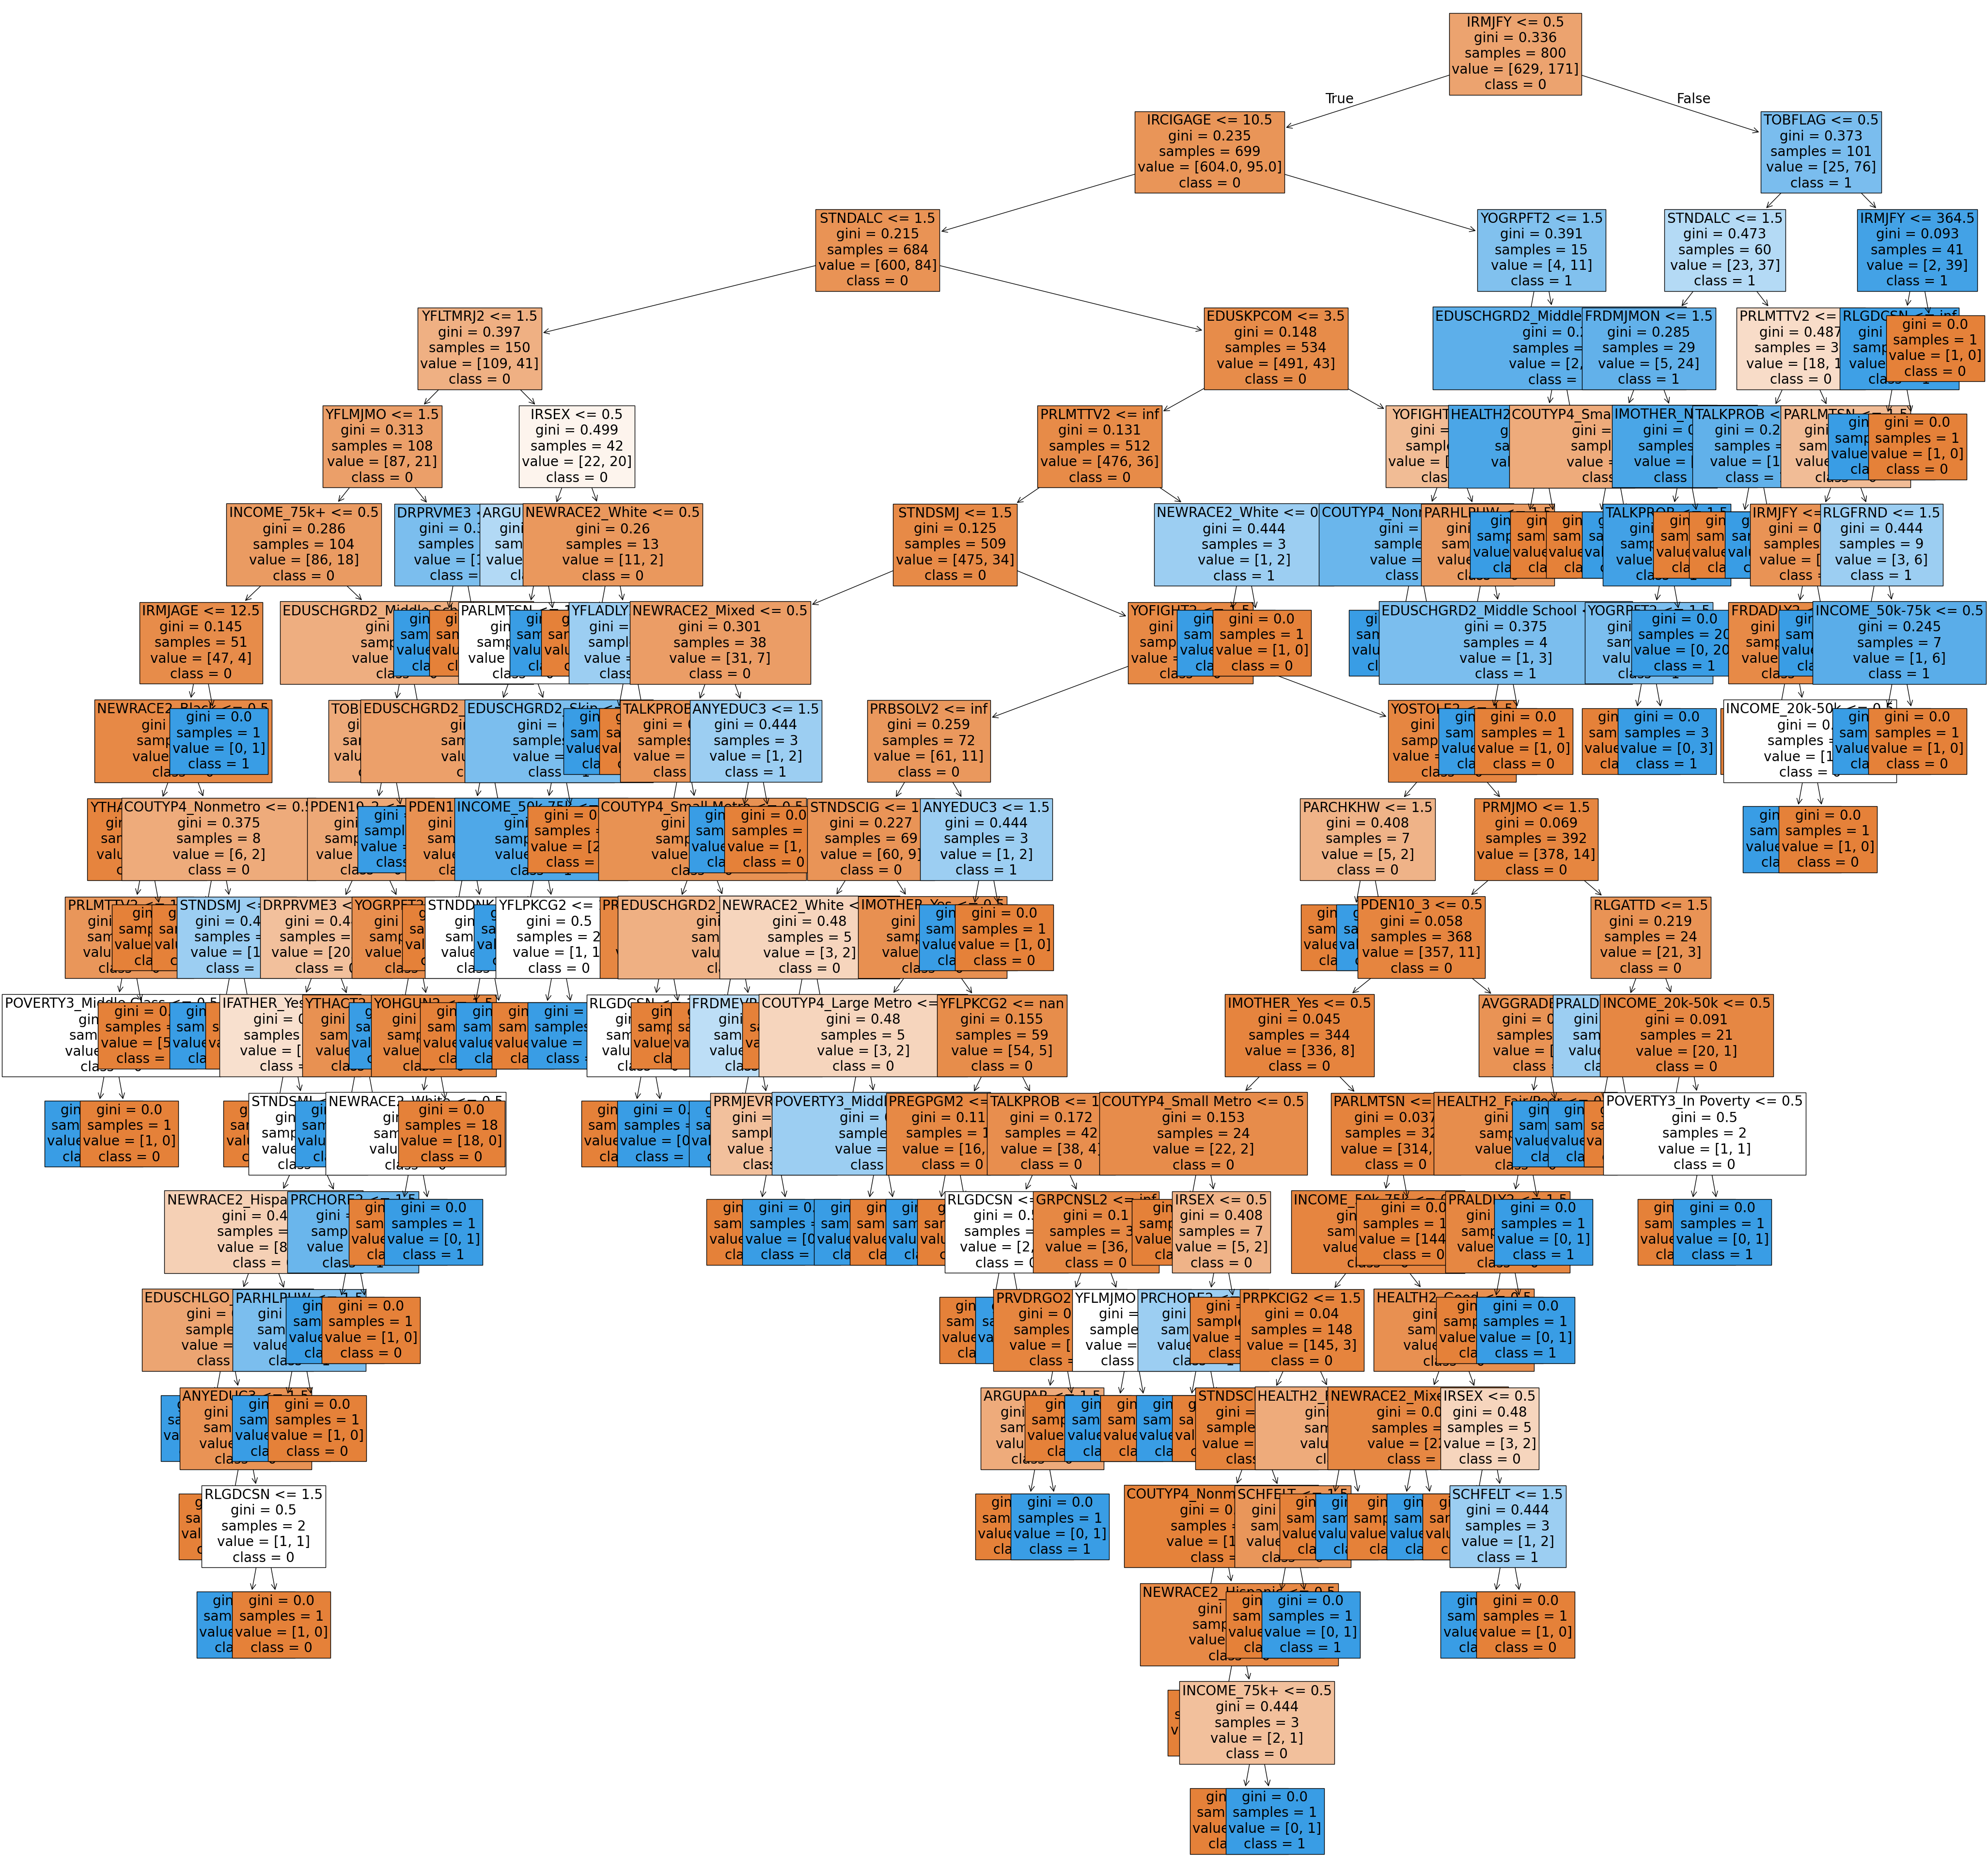

In [831]:
plt.figure(figsize = (50, 50))
plot_tree(tree_yth_bc
          , filled = True
          , feature_names = X_train.columns
          , class_names = ['0', '1']
          , label = 'all'
          , fontsize = 20)

plt.savefig('unpruned_binary_tree.png')
plt.show()

#### Cross Validation to Find Best Number of Leaves

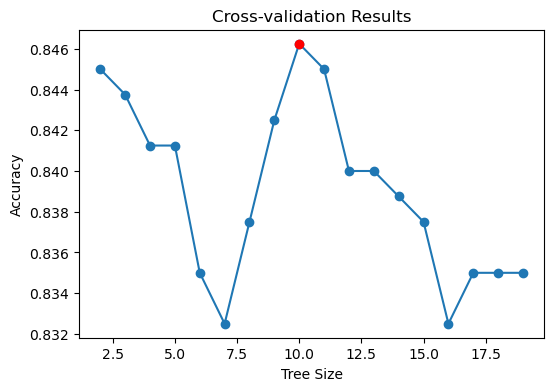

In [833]:
params = {'max_leaf_nodes': range(2, 20)}
cv_yth_bc = GridSearchCV(tree_yth_bc, params, cv = 10)
cv_yth_bc.fit(X_train, y_train)
cv_yth_bc_res = cv_yth_bc.cv_results_

best_size = cv_yth_bc.best_params_['max_leaf_nodes']
best_score = cv_yth_bc.best_score_

# plot results of cross-validation
plt.figure(figsize = (6, 4))
plt.plot(cv_yth_bc_res["param_max_leaf_nodes"], cv_yth_bc_res["mean_test_score"], 'o-')
plt.plot(best_size, best_score, 'ro-')
plt.xlabel('Tree Size')
plt.ylabel('Accuracy')
plt.title('Cross-validation Results');

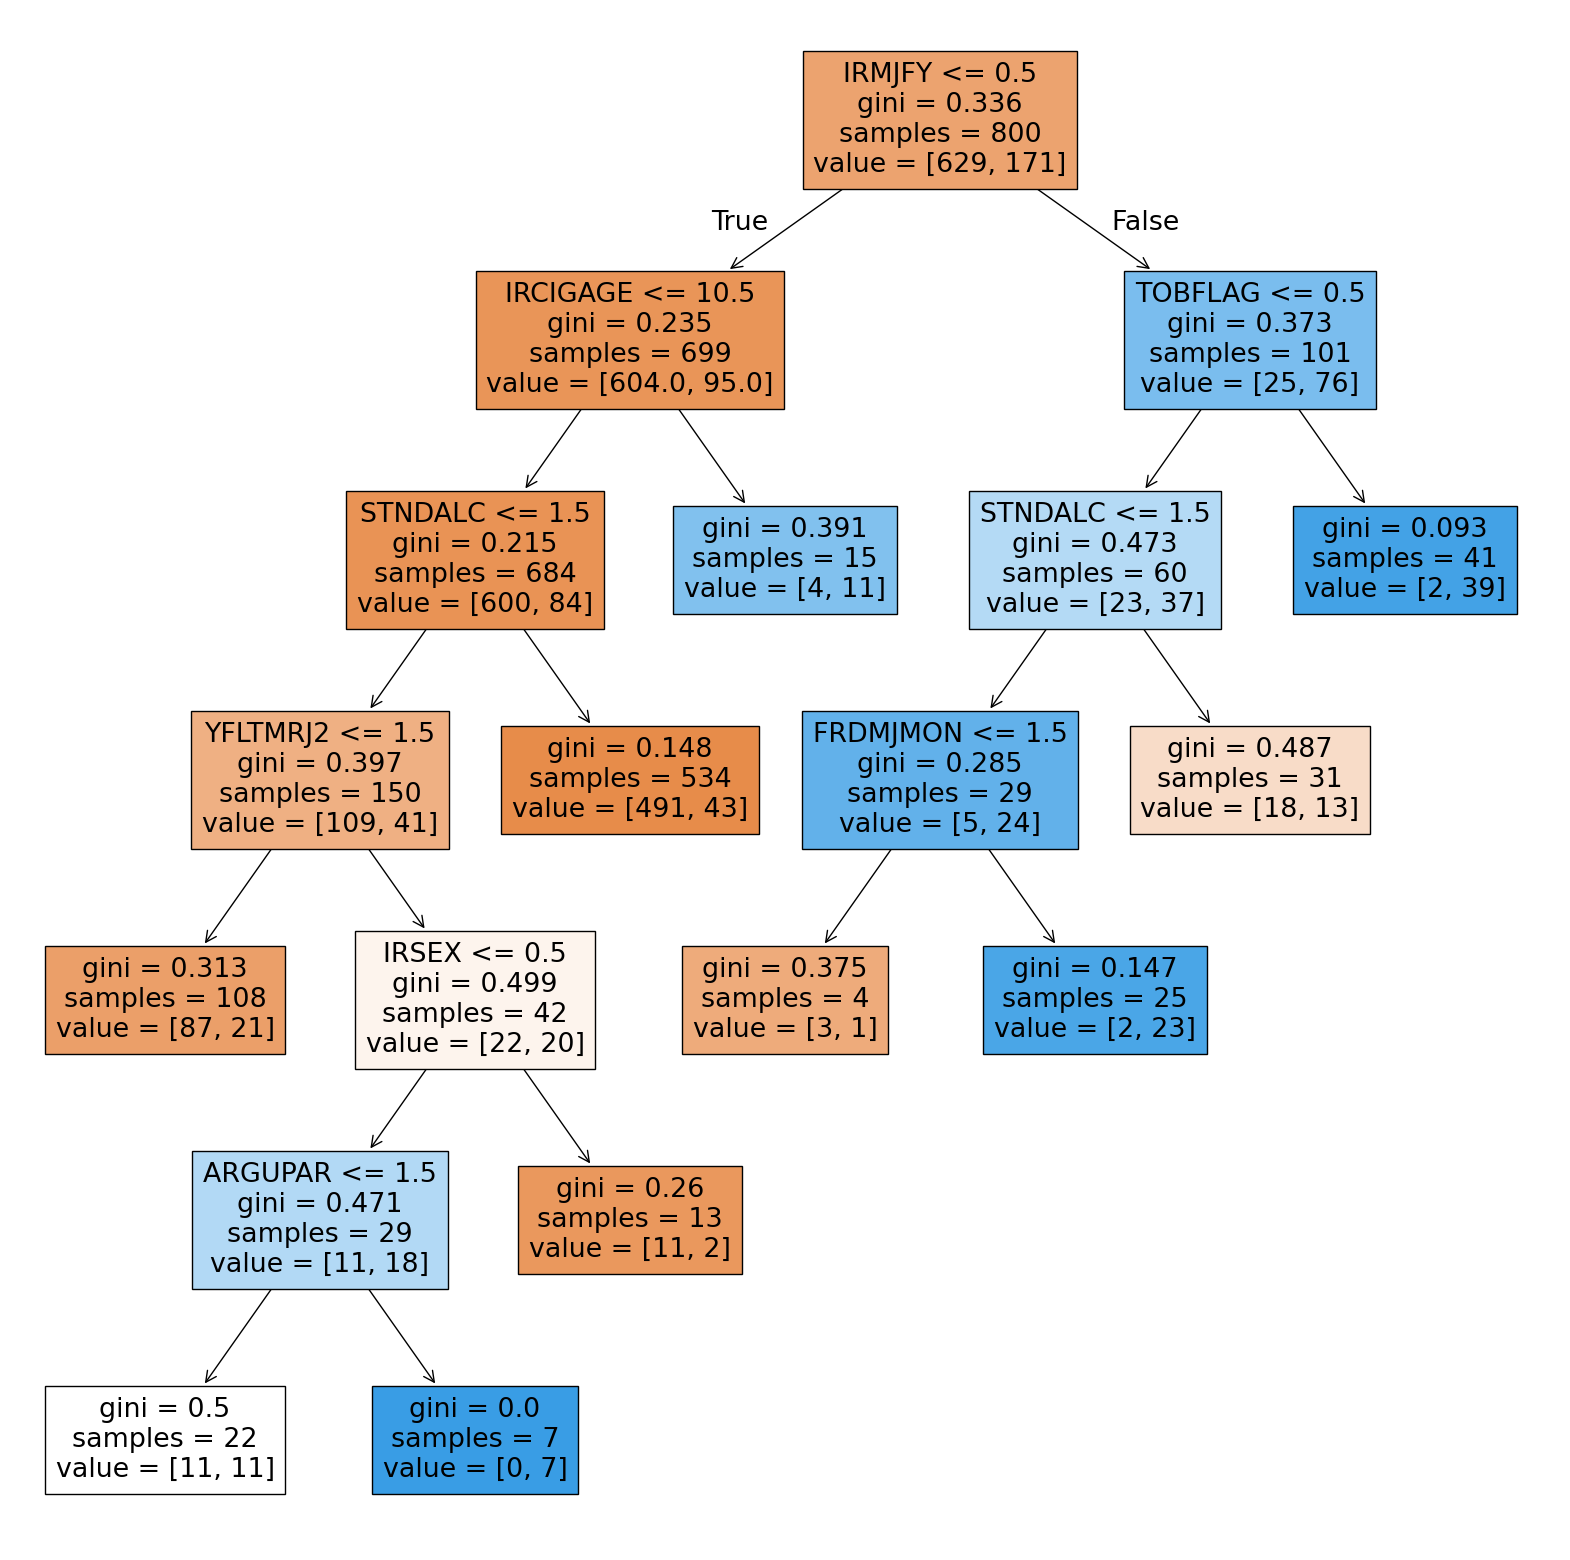

In [834]:
prune_yth_bc = DecisionTreeClassifier(max_leaf_nodes = best_size)
prune_yth_bc.fit(X_train, y_train)

y_pred_bc = prune_yth_bc.predict(X_test)

plt.figure(figsize = (20, 20))
plt.title('Pruned Tree')
plot_tree(prune_yth_bc, feature_names = X_train.columns, filled = True);

plt.savefig('pruned_binary_tree.png')

In [835]:
importances = pd.DataFrame({'feature_name': X_train.columns, 'importance': prune_yth_bc.feature_importances_})
importances = importances.sort_values('importance', ascending = False).reset_index(drop = True)

print(importances)

                   feature_name  importance
0                        IRMJFY    0.600918
1                       STNDALC    0.122706
2                      IRCIGAGE    0.098000
3                       TOBFLAG    0.048830
4                      YFLTMRJ2    0.042998
5                         IRSEX    0.035041
6                      FRDMJMON    0.027727
7                       ARGUPAR    0.023780
8                 EDUSCHLGO_Yes    0.000000
9                   IMOTHER_Yes    0.000000
10              EDUSCHGRD2_Skip    0.000000
11           EDUSCHGRD2_College    0.000000
12       EDUSCHGRD2_High School    0.000000
13     EDUSCHGRD2_Middle School    0.000000
14            EDUSCHLGO_Unknown    0.000000
15                 EDUSCHLGO_No    0.000000
16                 HEALTH2_Good    0.000000
17            HEALTH2_Fair/Poor    0.000000
18              IMOTHER_Unknown    0.000000
19            HEALTH2_Very Good    0.000000
20            HEALTH2_Excellent    0.000000
21            NEWRACE2_Hispanic 

Model Evaluation

In [840]:
print("Decision Tree Metrics:")
print(f"Precision: {precision_score(y_test, y_pred_bc):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_bc):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_bc):.4f}")
print("Training score: {:.2f}%".format(prune_yth_bc.score(X_train, y_train) * 100))
print("Test score: {:.2f}%".format(prune_yth_bc.score(X_test, y_test) * 100))


Decision Tree Metrics:
Precision: 0.7885
Recall: 0.3856
F1 Score: 0.5179
Training score: 87.62%
Test score: 83.58%


# Bagging

In [709]:
# Dropping encoded variables that also refer to alcohol use
patterns = ['ALCMDAYS']
drop_cols = yth_data_encoded.columns[yth_data_encoded.columns.str.contains('|'.join(patterns))]
yth_data_encoded_bag =  yth_data_encoded.copy().drop(columns = drop_cols)
yth_data_encoded_bag =  yth_data_encoded_bag.drop(columns = ["ALCFLAG", "IRALCAGE", "IRALCFM"])

X_train, X_test, y_train, y_test =  train_test_split(yth_data_encoded_bag.drop(['IRALCFY'], axis = 1)
                                                 , yth_data_encoded_bag['IRALCFY']
                                                 , train_size = 0.5, test_size = 0.5
                                                 , random_state = 1)

# fit Random Forests model
tree_yth_bag = RandomForestRegressor(max_features = X_train.shape[1], random_state = 1, n_estimators = len(yth_data_encoded_bag.columns) - 1)
tree_yth_bag.fit(X_train, y_train)
y_pred = tree_yth_bag.predict(X_test)

#### Bagging Metric Evaluation

In [711]:
print("Bagging Metrics:")
# Precision, recall, and f1 score couldn't handle multiple data types

print("Number of trees:", tree_yth_bag.n_estimators)
print("Number of features tried at each split:", tree_yth_bag.max_features)
print("Training score: {:.2f}%".format(tree_yth_bag.score(X_train, y_train) * 100))
print("Test score: {:.2f}%".format(tree_yth_bag.score(X_test, y_test) * 100))

Bagging Metrics:
Number of trees: 106
Number of features tried at each split: 106
Training score: 88.60%
Test score: 15.82%


In [715]:
importances_yth_bag = pd.DataFrame({'Feature': X_train.columns, 'Importance': tree_yth_bag.feature_importances_})
importances_yth_bag = importances_yth_bag.sort_values('Importance', ascending = False).reset_index(drop = True)

# display the table
print(importances_yth_bag)

                        Feature    Importance
0                        IRMJFY  1.991844e-01
1                       IRMJAGE  5.570744e-02
2                      IRCIGAGE  5.494089e-02
3                     EDUSKPCOM  3.867879e-02
4                      YFLADLY2  2.910481e-02
5                      YFLPKCG2  2.281504e-02
6                       IRCIGFM  2.248207e-02
7                       YOHGUN2  2.153226e-02
8                       STNDDNK  1.837012e-02
9                        IRMJFM  1.609044e-02
10                      RLGFRND  1.532632e-02
11                     YOSTOLE2  1.525002e-02
12                      ARGUPAR  1.419503e-02
13                      TOBFLAG  1.398597e-02
14               INCOME_50k-75k  1.278230e-02
15                     PARHLPHW  1.203157e-02
16                  IRSMKLSSTRY  1.167688e-02
17                  IRSMKLSS30N  1.152215e-02
18                      STNDALC  1.047094e-02
19                     FRDADLY2  1.008864e-02
20                     AVGGRADE  9

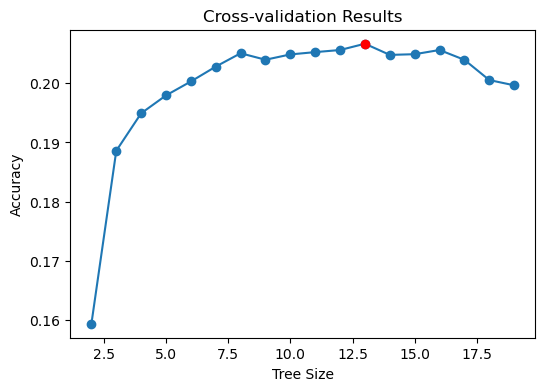

In [717]:
params = {'max_leaf_nodes': range(2, 20)}
cv_yth_bag = GridSearchCV(tree_yth_bag, params, cv = 5)
cv_yth_bag.fit(X_train, y_train)
cv_yth_bag_res = cv_yth_bag.cv_results_

best_size = cv_yth_bag.best_params_['max_leaf_nodes']
best_score = cv_yth_bag.best_score_

# plot results of cross-validation
plt.figure(figsize = (6, 4))
plt.plot(cv_yth_bag_res["param_max_leaf_nodes"], cv_yth_bag_res["mean_test_score"], 'o-')
plt.plot(best_size, best_score, 'ro-')
plt.xlabel('Tree Size')
plt.ylabel('Accuracy')
plt.title('Cross-validation Results');
plt.savefig('bagging_unpruned_tree.png')

In [718]:
print(cv_yth_bag_res["param_max_leaf_nodes"])
print(cv_yth_bag_res["mean_test_score"])

[2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19]
[0.1593871  0.18859194 0.19491581 0.19794038 0.20029142 0.20279889
 0.20505554 0.2039602  0.20485846 0.20524833 0.20560303 0.20666573
 0.20477929 0.20489611 0.20560624 0.20394619 0.20053037 0.19964457]


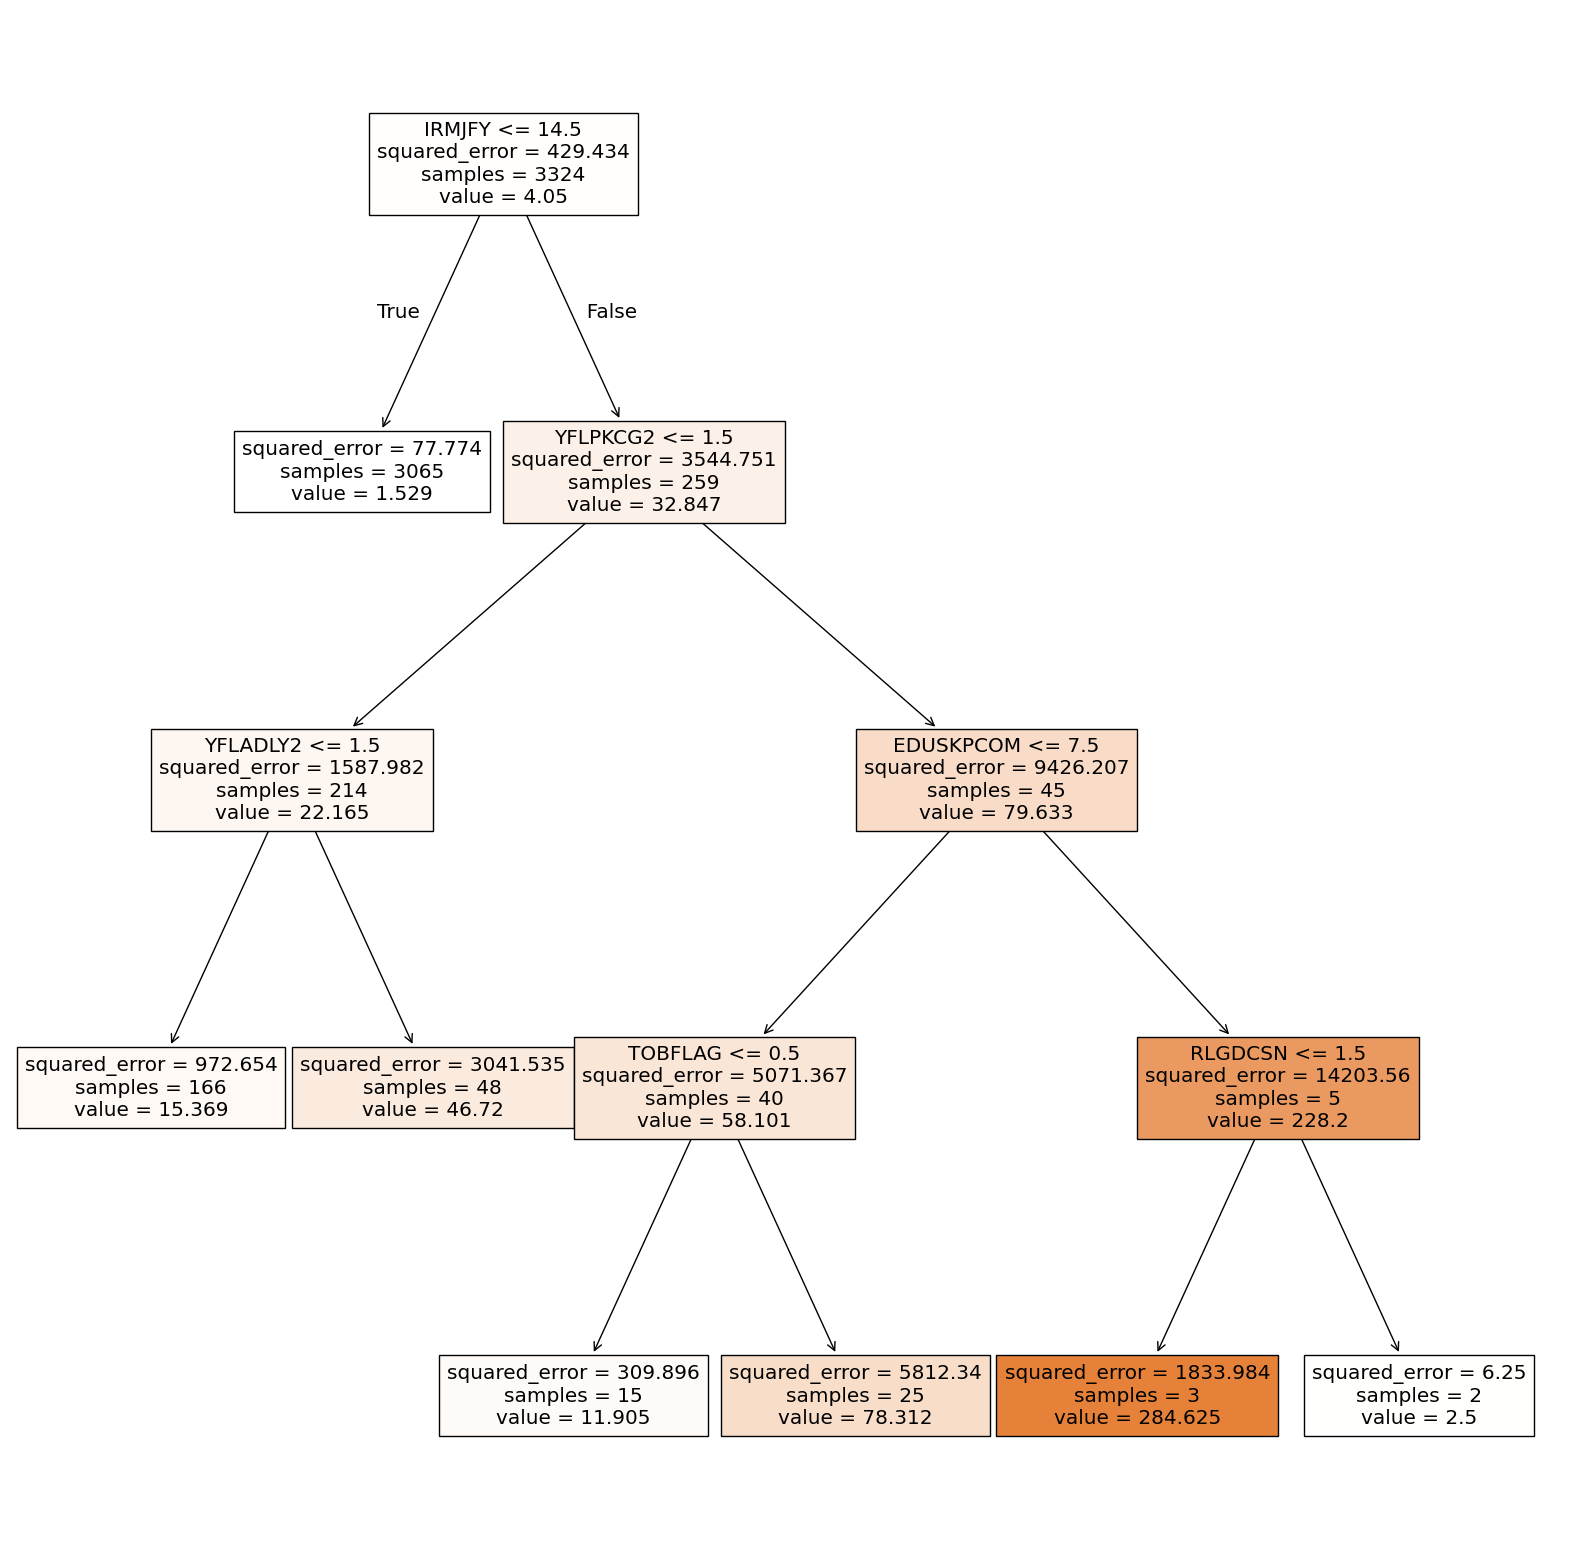

In [733]:
# I decided to override the best_size selection as the cv results for 7 leaf nodes was only 0.001 less than for 12

prune_yth_bag = RandomForestRegressor(max_leaf_nodes = 7, max_features = X_train.shape[1], random_state = 1, n_estimators = len(yth_data_encoded_bag.columns) - 1)
prune_yth_bag.fit(X_train, y_train)
y_pred = prune_yth_bag.predict(X_test)

plt.figure(figsize=(20, 20))
plt.title('Example Tree from Bagged Model')
tree_index = 0 
plot_tree(prune_yth_bag.estimators_[tree_index], 
          feature_names=X_train.columns, 
          filled=True)
plt.savefig('example_bag_tree.png')

In [735]:
print("Bagging Metrics:")
print("Training score: {:.2f}%".format(prune_yth_bag.score(X_train, y_train) * 100))
print("Test score: {:.2f}%".format(prune_yth_bag.score(X_test, y_test) * 100))

Bagging Metrics:
Training score: 39.92%
Test score: 15.34%


# Random Forest

In [739]:
# fit Random Forests model
# Dropping encoded variables that also refer to alcohol use
patterns = ['ALCMDAYS']
drop_cols = yth_data_encoded.columns[yth_data_encoded.columns.str.contains('|'.join(patterns))]
yth_data_encoded_rf =  yth_data_encoded.copy().drop(columns = drop_cols)
yth_data_encoded_rf =  yth_data_encoded_rf.drop(columns = ["ALCFLAG", "IRALCAGE", "IRALCFM"])

X_train, X_test, y_train, y_test =  train_test_split(yth_data_encoded_rf.drop(['IRALCFY'], axis = 1)
                                                 , yth_data_encoded_rf['IRALCFY']
                                                 , train_size = 0.5, test_size = 0.5
                                                 , random_state = 1)

tree_yth_rf = RandomForestRegressor(n_estimators = 100, max_features = 10, random_state = 1)
tree_yth_rf.fit(X_train, y_train)

# Predict values
y_pred_rf = tree_yth_rf.predict(X_test)

# find the MSE
print("Mean Squared Error: {:.2f}".format(mean_squared_error(y_test, y_pred_rf)))

Mean Squared Error: 281.56


In [741]:
print("Random Forest Metrics:")
print("Number of trees:", tree_yth_rf.n_estimators)
print("Number of features tried at each split:", tree_yth_rf.max_features)
print("Training score: {:.2f}%".format(tree_yth_rf.score(X_train, y_train) * 100))
print("Test score: {:.2f}%".format(tree_yth_rf.score(X_test, y_test) * 100))

importances_yth_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': tree_yth_rf.feature_importances_})
importances_yth_rf = importances_yth_rf.sort_values('Importance', ascending = False).reset_index(drop = True)

print(importances_yth_rf)

Random Forest Metrics:
Number of trees: 100
Number of features tried at each split: 10
Training score: 89.31%
Test score: 21.13%
                        Feature  Importance
0                        IRMJFY    0.068563
1                      IRCIGAGE    0.052042
2                       IRMJAGE    0.049718
3                        IRMJFM    0.035490
4                     EDUSKPCOM    0.027502
5                       TOBFLAG    0.026053
6                       MRJFLAG    0.021965
7                      YFLPKCG2    0.020749
8                 MRJMDAYS_None    0.019956
9                       IRCIGFM    0.019770
10                      YOHGUN2    0.018706
11                     YFLADLY2    0.017863
12                     YOSTOLE2    0.014919
13                      STNDDNK    0.014278
14                  IMOTHER_Yes    0.013571
15                      STNDALC    0.012313
16                  IRSMKLSSTRY    0.011830
17                     PRALDLY2    0.011669
18                      SCHFELT    

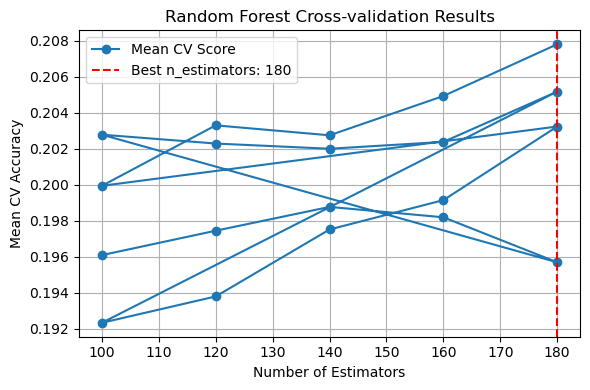

In [743]:
params = {'n_estimators': range(100, 200, 20), 'max_features': range(4, 12, 2)}

cv_yth_rf = GridSearchCV(tree_yth_rf, params, cv = 3)
cv_yth_rf.fit(X_train, y_train)
cv_yth_rf_res = cv_yth_rf.cv_results_

# Best params
best_n_estimators = cv_yth_rf.best_params_['n_estimators']
best_max_features = cv_yth_rf.best_params_['max_features']
best_score = cv_yth_rf.best_score_

plt.figure(figsize = (6, 4))
plt.plot(cv_yth_rf_res["param_n_estimators"], cv_yth_rf_res["mean_test_score"], 'o-', label = "Mean CV Score")
plt.axvline(best_n_estimators, color = 'red', linestyle = '--', label = f"Best n_estimators: {best_n_estimators}")
plt.xlabel('Number of Estimators')
plt.ylabel('Mean CV Accuracy')
plt.title('Random Forest Cross-validation Results')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('rf_cross_validation.png')
plt.show()


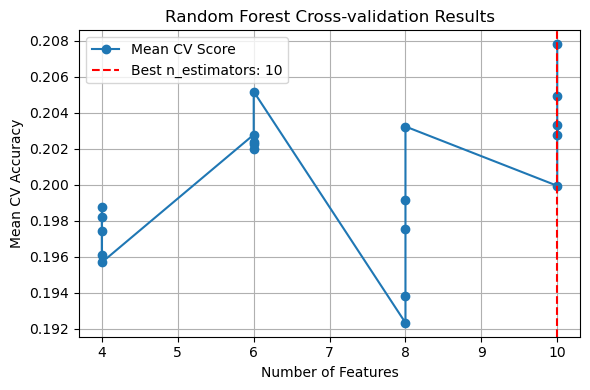

In [744]:
plt.figure(figsize = (6, 4))
plt.plot(cv_yth_rf_res["param_max_features"], cv_yth_rf_res["mean_test_score"], 'o-', label = "Mean CV Score")
plt.axvline(best_max_features, color = 'red', linestyle = '--', label = f"Best n_estimators: {best_max_features}")
plt.xlabel('Number of Features')
plt.ylabel('Mean CV Accuracy')
plt.title('Random Forest Cross-validation Results')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [745]:
print(cv_yth_rf.best_params_)

{'max_features': 10, 'n_estimators': 180}


In [746]:
# fit Random Forests model
pruned_tree_yth_rf = RandomForestRegressor(max_features = best_max_features, n_estimators = best_n_estimators, random_state = 1)
pruned_tree_yth_rf.fit(X_train, y_train)

# Predict values
y_pred_rf = pruned_tree_yth_rf.predict(X_test)

Model Evaluation Metrics

In [748]:
print("Random Forest Metrics:")
print("Number of trees:", pruned_tree_yth_rf.n_estimators)
print("Number of features tried at each split:", pruned_tree_yth_rf.max_features)
print("Training score: {:.2f}%".format(pruned_tree_yth_rf.score(X_train, y_train) * 100))
print("Test score: {:.2f}%".format(pruned_tree_yth_rf.score(X_test, y_test) * 100))

importances_yth_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': pruned_tree_yth_rf.feature_importances_})
importances_yth_rf = importances_yth_rf.sort_values('Importance', ascending = False).reset_index(drop = True)

print(importances_yth_rf)

Random Forest Metrics:
Number of trees: 180
Number of features tried at each split: 10
Training score: 89.33%
Test score: 21.75%
                        Feature  Importance
0                        IRMJFY    0.074167
1                       IRMJAGE    0.054025
2                      IRCIGAGE    0.046946
3                        IRMJFM    0.036249
4                       TOBFLAG    0.029236
5                     EDUSKPCOM    0.027313
6                 MRJMDAYS_None    0.019599
7                       MRJFLAG    0.019288
8                      YFLPKCG2    0.019134
9                       YOHGUN2    0.018061
10                      IRCIGFM    0.017975
11                     YFLADLY2    0.017281
12                      STNDDNK    0.016837
13                  IMOTHER_Yes    0.012662
14                     YOSTOLE2    0.012517
15                     PRALDLY2    0.012188
16                      STNDALC    0.012009
17                  IRSMKLSSTRY    0.011884
18                     FRDPCIG2    

# Boosting

Boosting has an issue with Nan values so these needed to be handled in order to run the model. 

In the bagging method Avg grade only had a 0.00985 importance so I decided that it would be okay to drop that column as %7 of it had Nan values

In [754]:
patterns = ['ALCMDAYS']
drop_cols = yth_data_encoded.columns[yth_data_encoded.columns.str.contains('|'.join(patterns))]
yth_data_encoded_bst =  yth_data_encoded.copy().drop(columns = drop_cols)
yth_data_encoded_bst =  yth_data_encoded_bst.drop(columns = ["ALCFLAG", "IRALCAGE", "IRALCFM", "AVGGRADE"])

yth_data_encoded_bst = yth_data_encoded_bst.dropna()

X_train, X_test, y_train, y_test =  train_test_split(yth_data_encoded_bst.drop(['IRALCFY'], axis = 1)
                                                 , yth_data_encoded_bst['IRALCFY']
                                                 , train_size = 0.5, test_size = 0.5
                                                 , random_state = 1)

In [756]:
# fit Gradient Boosting model
yth_encoded_boost = GradientBoostingRegressor(n_estimators = 500, max_depth = 4, random_state = 1)
yth_encoded_boost.fit(X_train, y_train)

# Predict medv
y_pred_boost = yth_encoded_boost.predict(X_test)

In [757]:
# create a dataframe of feature importances and their corresponding column names
importances_yth_boost = pd.DataFrame({'Feature': X_train.columns, 'Importance': yth_encoded_boost.feature_importances_})
importances_yth_boost = importances_yth_boost.sort_values('Importance', ascending = False).reset_index(drop = True)

# display the table
print(importances_yth_boost)

                        Feature    Importance
0                        IRMJFY  2.008821e-01
1                      IRCIGAGE  7.330838e-02
2                     EDUSKPCOM  6.205962e-02
3                       STNDDNK  4.435847e-02
4                      GRPCNSL2  4.245410e-02
5                        IRMJFM  3.943683e-02
6                       IRMJAGE  3.769407e-02
7                      PRCHORE2  2.551003e-02
8                NEWRACE2_Black  2.150401e-02
9                       YOHGUN2  1.918270e-02
10                     PRPKCIG2  1.878131e-02
11                     PRPROUD2  1.770491e-02
12                     PRALDLY2  1.748178e-02
13                      STNDALC  1.611912e-02
14                      SCHFELT  1.527941e-02
15                     PARLMTSN  1.527433e-02
16                      ARGUPAR  1.338820e-02
17           MRJMDAYS_Sometimes  1.312472e-02
18                  IRSMKLSSTRY  1.289725e-02
19            HEALTH2_Fair/Poor  1.256760e-02
20                     YFLADLY2  1

## Boosted Model Metrics

In [759]:
print("Boosting Metrics:")
print("Number of trees:", yth_encoded_boost.n_estimators)
print("Number of features tried at each split:", yth_encoded_boost.max_features)
print("Training score: {:.2f}%".format(yth_encoded_boost.score(X_train, y_train) * 100))
print("Test score: {:.2f}%".format(yth_encoded_boost.score(X_test, y_test) * 100))
print("Mean Squared Error: {:.2f}".format(mean_squared_error(y_test, y_pred_boost)))

Boosting Metrics:
Number of trees: 500
Number of features tried at each split: None
Training score: 95.29%
Test score: 7.37%
Mean Squared Error: 365.48


## Running Cross-Validation

In [761]:
param_grid = {
    'n_estimators': [100, 500],
    'learning_rate': [0.01, 0.1, 0.5],
    'max_depth': [2, 4]
}

cv_yth_bst = GridSearchCV(yth_encoded_boost, param_grid, cv = 3)
cv_yth_bst.fit(X_train, y_train)
cv_yth_bst_res = cv_yth_bst.cv_results_

print(cv_yth_bst.best_params_)
print(cv_yth_bst.best_score_)

{'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 500}
0.1319785701133794


In [795]:
yth_encoded_boost = GradientBoostingRegressor(n_estimators = 50, max_depth = 4, random_state = 1)
yth_encoded_boost.fit(X_train, y_train)

param_grid = {
    'n_estimators': [35, 45, 55, 65, 75, 85],
    'learning_rate': [0.05, 0.01],
    'max_depth': [2, 3]
}

cv_yth_bst = GridSearchCV(yth_encoded_boost, param_grid, cv = 3)
cv_yth_bst.fit(X_train, y_train)
cv_yth_bst_res = cv_yth_bst.cv_results_

print(cv_yth_bst.best_params_)
print(cv_yth_bst.best_score_)

{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 45}
0.14457190504413228


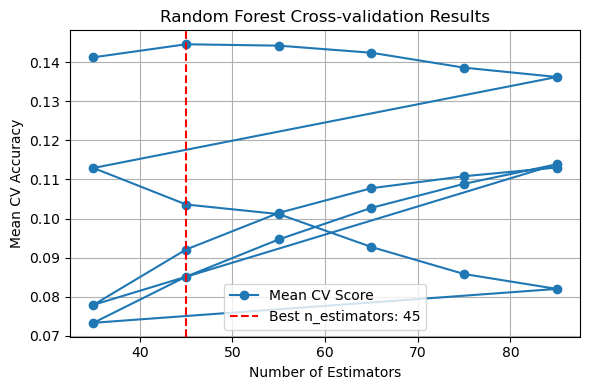

In [796]:
best_n_estimators = cv_yth_bst.best_params_['n_estimators']
best_learning_rate = cv_yth_bst.best_params_['learning_rate']
best_depth = cv_yth_bst.best_params_['max_depth']

plt.figure(figsize = (6, 4))
plt.plot(cv_yth_bst_res["param_n_estimators"], cv_yth_bst_res["mean_test_score"], 'o-', label = "Mean CV Score")
plt.axvline(best_n_estimators, color = 'red', linestyle = '--', label = f"Best n_estimators: {best_n_estimators}")
plt.xlabel('Number of Estimators')
plt.ylabel('Mean CV Accuracy')
plt.title('Random Forest Cross-validation Results')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


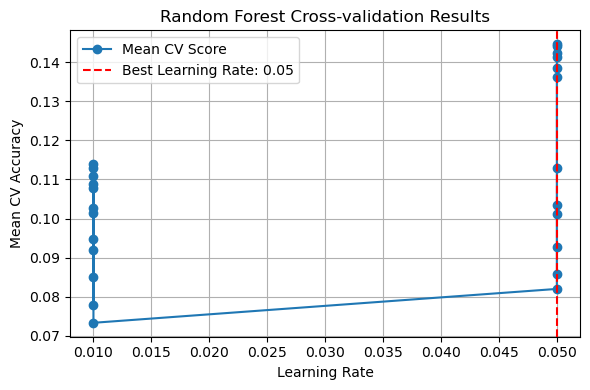

In [799]:
plt.figure(figsize = (6, 4))
plt.plot(cv_yth_bst_res["param_learning_rate"], cv_yth_bst_res["mean_test_score"], 'o-', label = "Mean CV Score")
plt.axvline(best_learning_rate, color = 'red', linestyle = '--', label = f"Best Learning Rate: {best_learning_rate}")
plt.xlabel('Learning Rate')
plt.ylabel('Mean CV Accuracy')
plt.title('Random Forest Cross-validation Results')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

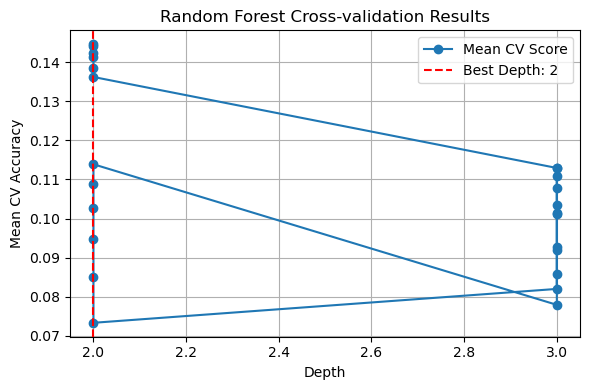

In [801]:
plt.figure(figsize = (6, 4))
plt.plot(cv_yth_bst_res["param_max_depth"], cv_yth_bst_res["mean_test_score"], 'o-', label = "Mean CV Score")
plt.axvline(best_depth, color = 'red', linestyle = '--', label = f"Best Depth: {best_depth}")
plt.xlabel('Depth')
plt.ylabel('Mean CV Accuracy')
plt.title('Random Forest Cross-validation Results')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Pruned Boost Metrics

In [764]:
# fit the Gradient Boosting model
pruned_yth_boost = GradientBoostingRegressor(n_estimators = 150, max_depth = 3, random_state = 1, 
                                             learning_rate = 0.05)
pruned_yth_boost.fit(X_train, y_train)

# Predict medv
y_pred_boost = pruned_yth_boost.predict(X_test)

In [765]:
print("Boosting Metrics:")
print("Number of trees:", yth_encoded_boost.n_estimators)
print("Number of features tried at each split:", yth_encoded_boost.max_features)
print("Training score: {:.2f}%".format(yth_encoded_boost.score(X_train, y_train) * 100))
print("Test score: {:.2f}%".format(yth_encoded_boost.score(X_test, y_test) * 100))
print("Mean Squared Error: {:.2f}".format(mean_squared_error(y_test, y_pred_boost)))

Boosting Metrics:
Number of trees: 100
Number of features tried at each split: None
Training score: 81.66%
Test score: 12.74%
Mean Squared Error: 322.76


In [766]:
# create a dataframe of feature importances and their corresponding column names
importances_yth_boost = pd.DataFrame({'Feature': X_train.columns, 'Importance': pruned_yth_boost.feature_importances_})
importances_yth_boost = importances_yth_boost.sort_values('Importance', ascending = False).reset_index(drop = True)

# display the table
print(importances_yth_boost)

                        Feature  Importance
0                        IRMJFY    0.272997
1                      IRCIGAGE    0.142662
2                     EDUSKPCOM    0.078542
3                      GRPCNSL2    0.058973
4                        IRMJFM    0.039559
5                       IRMJAGE    0.038951
6                       STNDDNK    0.038924
7                      PRPROUD2    0.024451
8                       STNDALC    0.024297
9            MRJMDAYS_Sometimes    0.020627
10               NEWRACE2_Black    0.018193
11                      TOBFLAG    0.017484
12                      IRCIGFM    0.017055
13                  IRSMKLSSTRY    0.015570
14                     PRVDRGO2    0.013589
15               NEWRACE2_White    0.012824
16                     YFLADLY2    0.012774
17                      YOHGUN2    0.012726
18                     PRALDLY2    0.011687
19                     FRDADLY2    0.011278
20                      RLGDCSN    0.011258
21                     PRPKCIG2 